In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import kagglehub

ModuleNotFoundError: No module named 'kagglehub'

# Initial Data Ingestion

In [ ]:
# Download latest version
path = kagglehub.dataset_download("mohamedalqblawi/rplan-pickle-files")

print("Path to dataset files:", path)

# Reading In Sample File

In [5]:
test_path = ".cache/kagglehub/datasets/mohamedalqblawi/rplan-pickle-files/versions/1/pickle/train/0.pkl"
test_file = pd.read_pickle(test_path)

In [6]:
len(test_file)

5

In [ ]:
# Four masks, each 256 x 256
np.array(test_file[0:4]).shape

(4, 256, 256)

# Examining Sample Meta Data

In [4]:
test_file[4]

[{'category': 0, 'centroid': (134, 153)},
 {'category': 2, 'centroid': (68, 129)},
 {'category': 7, 'centroid': (106, 98)},
 {'category': 3, 'centroid': (143, 89)},
 {'category': 1, 'centroid': (190, 98)},
 {'category': 9, 'centroid': (217, 156)}]

# Visualizing All Layers Stacked

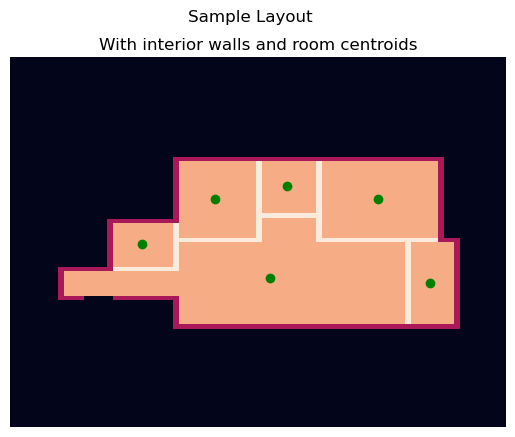

In [ ]:
# recovering walls through elementise addition
walls = np.sum(test_file[2:4], axis=0) * 50

n = len(test_file)
fig, ax = plt.subplots()

sns.heatmap(np.sum([test_file[0], test_file[1]+100, walls], axis=0).T, 
            ax=ax, cbar=False, xticklabels=False, yticklabels=False)

for room in test_file[4]:
    ax.scatter(room["centroid"][0], 
               room["centroid"][1], 
               color="green")

ax.set_title("With interior walls and room centroids")

plt.suptitle("Sample Layout")
plt.show()

# Visualizing Boundary Masks

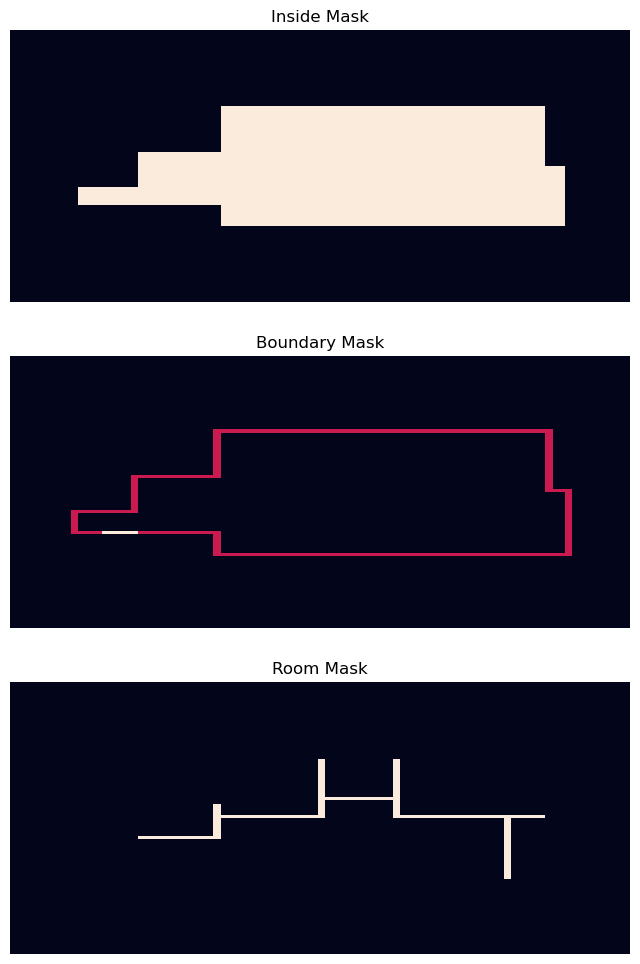

In [7]:
masks = test_file[0:2]
masks.append(np.sum(test_file[2:4], axis=0))
fig, ax = plt.subplots(len(masks), figsize=(8, 12))

for i, mask in enumerate(masks):
    sns.heatmap(mask.T, ax=ax[i], cbar=False, xticklabels=False, yticklabels=False)

ax[0].set_title("Inside Mask")
ax[1].set_title("Boundary Mask")
ax[2].set_title("Room Mask")

plt.show()